In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, normaltest, levene, chisquare, shapiro, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

## Выгрузка, изучение и предобработка данных

### users_test

In [2]:
# Открываем и сохраняем датасет в переменную users_test
users_test = pd.read_csv('Проект_3_users_test.csv', sep=';')
users_test.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892309896,27,685,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12,16,17",1,24,30,89,NaN,NaN,0
1,892044516,27,0,NaN,Germany,NaN,1,24,30,0,NaN,NaN,0
2,892185708,45,44,NaN,Israel,"1,3,4,6,7,8,10,11,12,13,14,15,16,17,18,19,20,2...",1,42,48,68,NaN,NaN,0
3,892130292,32,0,NaN,United States of America,"1,2,3,4,5,6,7,8,9,10,11,12",1,29,35,0,NaN,NaN,0
4,891406035,27,1000,NaN,France,NaN,1,24,30,1,1.0,NaN,0


In [3]:
users_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4308 entries, 0 to 4307
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4308 non-null   int64  
 1   age               4308 non-null   int64  
 2   attraction_coeff  4308 non-null   int64  
 3   coins             49 non-null     float64
 4   country           4308 non-null   object 
 5   visit_days        2978 non-null   object 
 6   gender            4308 non-null   int64  
 7   age_filter_start  4308 non-null   int64  
 8   age_filter_end    4308 non-null   int64  
 9   views_count       4308 non-null   int64  
 10  was_premium       408 non-null    float64
 11  is_premium        157 non-null    float64
 12  total_revenue     4308 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 437.7+ KB


In [4]:
# Меняем NaN значения на 0 в колонках was_premium и is_premium, приводим к единому типу данных
users_test['was_premium'] = users_test['was_premium'].fillna(0).astype(int)
users_test['is_premium'] = users_test['is_premium'].fillna(0).astype(int)
users_test['coins'] = users_test['coins'].fillna(0)

In [5]:
users_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4308 entries, 0 to 4307
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4308 non-null   int64  
 1   age               4308 non-null   int64  
 2   attraction_coeff  4308 non-null   int64  
 3   coins             4308 non-null   float64
 4   country           4308 non-null   object 
 5   visit_days        2978 non-null   object 
 6   gender            4308 non-null   int64  
 7   age_filter_start  4308 non-null   int64  
 8   age_filter_end    4308 non-null   int64  
 9   views_count       4308 non-null   int64  
 10  was_premium       4308 non-null   int64  
 11  is_premium        4308 non-null   int64  
 12  total_revenue     4308 non-null   int64  
dtypes: float64(1), int64(10), object(2)
memory usage: 437.7+ KB


Значения в столбце visit_days по сути списки и Nan значения, но выгрузились как строки и Nan. Напишем функцию и преобразуем данные строки в списки. Nan значения преобразуем в пустой список.

In [6]:
def parse_visit_days(val):
    if pd.isna(val):
        return []
    if isinstance(val, str):
        val = val.strip()
        if val.startswith('[') and val.endswith(']'):
            val = val[1:-1]
        parts = val.split(',')
        result = []
        for part in parts:
            part = part.strip()
            if part:
                try:
                    result.append(int(part))
                except:
                    pass
        return result
users_test['visit_days'] = users_test['visit_days'].apply(parse_visit_days)    

In [7]:
users_test.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892309896,27,685,0.0,United States of America,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16, 17]",1,24,30,89,0,0,0
1,892044516,27,0,0.0,Germany,[],1,24,30,0,0,0,0
2,892185708,45,44,0.0,Israel,"[1, 3, 4, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16,...",1,42,48,68,0,0,0
3,892130292,32,0,0.0,United States of America,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",1,29,35,0,0,0,0
4,891406035,27,1000,0.0,France,[],1,24,30,1,1,0,0


### users_control_1

In [8]:
# Открываем и сохраняем датасет в переменную users_control_1
users_control_1 = pd.read_csv('Проект_3_users_control_1.csv', sep=';')
users_control_1.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892319115,25,435,NaN,United States of America,"1,2,3,4,5,6",0,22,32,982,NaN,NaN,0
1,891248523,29,500,NaN,United States of America,"1,2",1,26,32,12,NaN,NaN,0
2,891670932,33,800,NaN,France,"1,2,3,5,6,8,9,11,13,16",1,30,36,5,NaN,NaN,0
3,891060786,26,0,NaN,Argentina,"1,2,3,4,5",1,23,29,0,NaN,NaN,0
4,892006554,35,294,NaN,United States of America,"1,2,3,5,6,7,8,9,10,12,15,16,17,19",1,30,40,17,NaN,NaN,0


In [9]:
users_control_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4340 non-null   int64  
 1   age               4340 non-null   int64  
 2   attraction_coeff  4340 non-null   int64  
 3   coins             60 non-null     float64
 4   country           4340 non-null   object 
 5   visit_days        3016 non-null   object 
 6   gender            4340 non-null   int64  
 7   age_filter_start  4340 non-null   int64  
 8   age_filter_end    4340 non-null   int64  
 9   views_count       4340 non-null   int64  
 10  was_premium       436 non-null    float64
 11  is_premium        192 non-null    float64
 12  total_revenue     4340 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 440.9+ KB


In [10]:
# Меняем NaN значения на 0 в колонках was_premium и is_premium, приводим к единому типу данных
users_control_1['was_premium'] = users_control_1['was_premium'].fillna(0).astype(int)
users_control_1['is_premium'] = users_control_1['is_premium'].fillna(0).astype(int)
users_control_1['coins'] = users_control_1['coins'].fillna(0)

In [11]:
users_control_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4340 non-null   int64  
 1   age               4340 non-null   int64  
 2   attraction_coeff  4340 non-null   int64  
 3   coins             4340 non-null   float64
 4   country           4340 non-null   object 
 5   visit_days        3016 non-null   object 
 6   gender            4340 non-null   int64  
 7   age_filter_start  4340 non-null   int64  
 8   age_filter_end    4340 non-null   int64  
 9   views_count       4340 non-null   int64  
 10  was_premium       4340 non-null   int64  
 11  is_premium        4340 non-null   int64  
 12  total_revenue     4340 non-null   int64  
dtypes: float64(1), int64(10), object(2)
memory usage: 440.9+ KB


Преобразуем значения в колокне visit_days

In [12]:
def parse_visit_days(val):
    if pd.isna(val):
        return []
    if isinstance(val, str):
        val = val.strip()
        if val.startswith('[') and val.endswith(']'):
            val = val[1:-1]
        parts = val.split(',')
        result = []
        for part in parts:
            part = part.strip()
            if part:
                try:
                    result.append(int(part))
                except:
                    pass
        return result
users_control_1['visit_days'] = users_control_1['visit_days'].apply(parse_visit_days)    

In [13]:
users_control_1.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892319115,25,435,0.0,United States of America,"[1, 2, 3, 4, 5, 6]",0,22,32,982,0,0,0
1,891248523,29,500,0.0,United States of America,"[1, 2]",1,26,32,12,0,0,0
2,891670932,33,800,0.0,France,"[1, 2, 3, 5, 6, 8, 9, 11, 13, 16]",1,30,36,5,0,0,0
3,891060786,26,0,0.0,Argentina,"[1, 2, 3, 4, 5]",1,23,29,0,0,0,0
4,892006554,35,294,0.0,United States of America,"[1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 15, 16, 17, 19]",1,30,40,17,0,0,0


### users_control_2

In [14]:
# Открываем и сохраняем датасет в переменную users_control_2
users_control_2 = pd.read_csv('Проект_3_users_control_2.csv', sep=';')
users_control_2.head()

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
0,892035504,37,137,NaN,Israel,"1,2,3,4,5,6,7,8,9,11,13",1,30,40,51,NaN,NaN,0
1,891782112,57,0,NaN,Italy,1,1,54,60,0,NaN,NaN,0
2,891110337,30,769,NaN,France,"1,2,3,4,5",1,27,33,13,NaN,NaN,0
3,891796320,48,750,NaN,France,"1,4,6,8,10,11,12,14,15,16,18",1,45,51,12,NaN,NaN,0
4,891880212,54,638,NaN,United States of America,1,1,35,53,94,NaN,NaN,0


In [15]:
users_control_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4264 entries, 0 to 4263
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4264 non-null   int64  
 1   age               4264 non-null   int64  
 2   attraction_coeff  4264 non-null   int64  
 3   coins             61 non-null     float64
 4   country           4264 non-null   object 
 5   visit_days        2900 non-null   object 
 6   gender            4264 non-null   int64  
 7   age_filter_start  4264 non-null   int64  
 8   age_filter_end    4264 non-null   int64  
 9   views_count       4264 non-null   int64  
 10  was_premium       411 non-null    float64
 11  is_premium        191 non-null    float64
 12  total_revenue     4264 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 433.2+ KB


In [16]:
# Меняем NaN значения на 0 в колонках was_premium и is_premium, приводим к единому типу данных
users_control_2['was_premium'] = users_control_2['was_premium'].fillna(0).astype(int)
users_control_2['is_premium'] = users_control_2['is_premium'].fillna(0).astype(int)
users_control_2['coins'] = users_control_2['coins'].fillna(0)

In [17]:
users_control_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4264 entries, 0 to 4263
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               4264 non-null   int64  
 1   age               4264 non-null   int64  
 2   attraction_coeff  4264 non-null   int64  
 3   coins             4264 non-null   float64
 4   country           4264 non-null   object 
 5   visit_days        2900 non-null   object 
 6   gender            4264 non-null   int64  
 7   age_filter_start  4264 non-null   int64  
 8   age_filter_end    4264 non-null   int64  
 9   views_count       4264 non-null   int64  
 10  was_premium       4264 non-null   int64  
 11  is_premium        4264 non-null   int64  
 12  total_revenue     4264 non-null   int64  
dtypes: float64(1), int64(10), object(2)
memory usage: 433.2+ KB


Преобразуем значения в колокне visit_days

In [18]:
def parse_visit_days(val):
    if pd.isna(val):
        return []
    if isinstance(val, str):
        val = val.strip()
        if val.startswith('[') and val.endswith(']'):
            val = val[1:-1]
        parts = val.split(',')
        result = []
        for part in parts:
            part = part.strip()
            if part:
                try:
                    result.append(int(part))
                except:
                    pass
        return result
users_control_2['visit_days'] = users_control_2['visit_days'].apply(parse_visit_days)    

### transactions_test

In [19]:
# Открываем и сохраняем датасет в переменную transactions_test
transactions_test = pd.read_csv('Проект_3_transactions_test.csv', sep=';')

transactions_test.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type
3,892236423,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783,67,menu,other_type
4,892168170,United States of America,2017-10-19 17:10:00,2017-10-27 19:10:00,9087,147,trial_vip_popup,trial_premium


In [20]:
transactions_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   uid           273 non-null    int64 
 1   country       273 non-null    object
 2   joined_at     273 non-null    object
 3   paid_at       273 non-null    object
 4   revenue       273 non-null    int64 
 5   payment_id    273 non-null    int64 
 6   from_page     273 non-null    object
 7   product_type  273 non-null    object
dtypes: int64(3), object(5)
memory usage: 17.2+ KB


In [21]:
# Меняем тип данных в колонках joined_at и paid_at на даду и время
transactions_test['joined_at'] = pd.to_datetime(transactions_test['joined_at'])
transactions_test['paid_at'] = pd.to_datetime(transactions_test['paid_at'])
transactions_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   uid           273 non-null    int64         
 1   country       273 non-null    object        
 2   joined_at     273 non-null    datetime64[ns]
 3   paid_at       273 non-null    datetime64[ns]
 4   revenue       273 non-null    int64         
 5   payment_id    273 non-null    int64         
 6   from_page     273 non-null    object        
 7   product_type  273 non-null    object        
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 17.2+ KB


In [22]:
transactions_test.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891345942,Italy,2017-05-11 13:00:00,2017-11-13 15:04:00,12909,147,trial_vip_popup,trial_premium
1,892054251,United States of America,2017-10-22 00:33:00,2017-10-30 01:37:00,13923,147,trial_vip_popup,trial_premium
2,892236423,United States of America,2017-10-18 01:09:00,2017-10-23 00:15:00,3783,67,menu,other_type
3,892236423,United States of America,2017-10-18 01:09:00,2017-10-27 22:38:00,3783,67,menu,other_type
4,892168170,United States of America,2017-10-19 17:10:00,2017-10-27 19:10:00,9087,147,trial_vip_popup,trial_premium


In [23]:
# количество уникальных пользователей
transactions_test.uid.nunique()

146

### transactions_control_1

In [24]:
# Открываем и сохраняем датасет в переменную transactions_control_1
transactions_control_1 = pd.read_csv('Проект_3_transactions_control_1.csv', sep=';')
transactions_control_1.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891319275.0,France,2017-05-11 19:57:00,2017-12-11 21:57:00,12727.0,147.0,trial_vip_popup,trial_premium
1,892421826.0,Israel,2017-10-14 12:46:00,2017-10-23 12:54:00,14586.0,147.0,trial_vip_popup,trial_premium
2,891822480.0,Italy,2017-10-26 22:27:00,2017-12-11 20:59:00,1911.0,19.0,none,coins
3,891367521.0,Italy,2017-05-11 02:37:00,2017-06-11 19:15:00,1456.0,127.0,sympathy,other_type
4,892207959.0,France,2017-10-18 18:30:00,2017-12-11 12:03:00,1261.0,19.0,empty_likes,coins


In [25]:
transactions_control_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uid           377 non-null    float64
 1   country       377 non-null    object 
 2   joined_at     1007 non-null   object 
 3   paid_at       1007 non-null   object 
 4   revenue       377 non-null    float64
 5   payment_id    377 non-null    float64
 6   from_page     377 non-null    object 
 7   product_type  377 non-null    object 
dtypes: float64(3), object(5)
memory usage: 63.1+ KB


Количество строк в колонках с датами значительно превышает количество непустных значений в остальных колонках. 
Возможно, что при выгрузке данных, подтянулись пустые логи. 

In [26]:
# Посмотрим на эти сроки
transactions_control_1[transactions_control_1.uid.isna()]
# 630 пустых строк

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
377,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
378,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
379,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
380,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
381,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1002,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1003,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1004,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN
1005,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN


In [27]:
# Удалим пустые строки
transactions_control_1 = transactions_control_1.dropna(subset=['uid'])
transactions_control_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 377 entries, 0 to 376
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uid           377 non-null    float64
 1   country       377 non-null    object 
 2   joined_at     377 non-null    object 
 3   paid_at       377 non-null    object 
 4   revenue       377 non-null    float64
 5   payment_id    377 non-null    float64
 6   from_page     377 non-null    object 
 7   product_type  377 non-null    object 
dtypes: float64(3), object(5)
memory usage: 26.5+ KB


In [28]:
# Меняем тип данных в колонках joined_at и paid_at на даду и время
# Приводим тип данных в колонках uid, revenue, payment_id к типу int
transactions_control_1['joined_at'] = pd.to_datetime(transactions_control_1.iloc[:, 2])
transactions_control_1['paid_at'] = pd.to_datetime(transactions_control_1.iloc[:, 3])
transactions_control_1 = transactions_control_1.astype({'revenue': int, 'payment_id': int, 'uid': int})
transactions_control_1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 377 entries, 0 to 376
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   uid           377 non-null    int64         
 1   country       377 non-null    object        
 2   joined_at     377 non-null    datetime64[ns]
 3   paid_at       377 non-null    datetime64[ns]
 4   revenue       377 non-null    int64         
 5   payment_id    377 non-null    int64         
 6   from_page     377 non-null    object        
 7   product_type  377 non-null    object        
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 26.5+ KB


In [29]:
transactions_control_1.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891319275,France,2017-05-11 19:57:00,2017-12-11 21:57:00,12727,147,trial_vip_popup,trial_premium
1,892421826,Israel,2017-10-14 12:46:00,2017-10-23 12:54:00,14586,147,trial_vip_popup,trial_premium
2,891822480,Italy,2017-10-26 22:27:00,2017-12-11 20:59:00,1911,19,none,coins
3,891367521,Italy,2017-05-11 02:37:00,2017-06-11 19:15:00,1456,127,sympathy,other_type
4,892207959,France,2017-10-18 18:30:00,2017-12-11 12:03:00,1261,19,empty_likes,coins


In [30]:
# количество уникальных пользователей
transactions_control_1.uid.nunique()

193

### transactions_control_2

In [31]:
transactions_control_2 = pd.read_csv('Проект_3_transactions_control_2.csv', sep=';')
transactions_control_2.head()

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891266616,Argentina,2017-06-11 15:25:00,2017-10-11 17:35:00,6305,19,autorefill,coins
1,892186737,Chile,2017-10-19 06:03:00,2017-04-11 08:53:00,4732,147,promo_09,premium_no_trial
2,891959004,United States of America,2017-10-24 00:12:00,2017-10-31 02:12:00,10153,147,trial_vip_popup,trial_premium
3,892115478,Spain,2017-10-20 20:39:00,2017-10-26 06:26:00,2366,67,empty_likes,other_type
4,891592941,Switzerland,2017-10-31 12:40:00,2017-03-11 16:25:00,6292,147,promo_09,premium_no_trial


In [32]:
transactions_control_2.query('uid==891266616')

,uid,country,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,891266616,Argentina,2017-06-11 15:25:00,2017-10-11 17:35:00,6305,19,autorefill,coins
46,891266616,Argentina,2017-06-11 15:25:00,2017-08-11 05:22:00,6305,19,empty_likes,coins
156,891266616,Argentina,2017-06-11 15:25:00,2017-07-11 00:08:00,6292,147,promo_09,premium_no_trial


In [33]:
transactions_control_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   uid           328 non-null    int64 
 1   country       328 non-null    object
 2   joined_at     328 non-null    object
 3   paid_at       328 non-null    object
 4   revenue       328 non-null    int64 
 5   payment_id    328 non-null    int64 
 6   from_page     328 non-null    object
 7   product_type  328 non-null    object
dtypes: int64(3), object(5)
memory usage: 20.6+ KB


In [34]:
# Меняем тип данных в колонках joined_at и paid_at на даду и время
transactions_control_2['joined_at'] = pd.to_datetime(transactions_control_2.iloc[:, 2])
transactions_control_2['paid_at'] = pd.to_datetime(transactions_control_2.iloc[:, 3])

In [35]:
transactions_control_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   uid           328 non-null    int64         
 1   country       328 non-null    object        
 2   joined_at     328 non-null    datetime64[ns]
 3   paid_at       328 non-null    datetime64[ns]
 4   revenue       328 non-null    int64         
 5   payment_id    328 non-null    int64         
 6   from_page     328 non-null    object        
 7   product_type  328 non-null    object        
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 20.6+ KB


In [36]:
# количество уникальных пользователей
transactions_control_2.uid.nunique()

187

## Объединяем датафреймы users_* и transactions_*

### Тестовая группа

In [37]:
test = users_test.merge(transactions_test, on='uid', how='left')
# Заменяем Nan в revenue на 0
test.revenue = test.revenue.fillna(0).astype(int)
test.head()

,uid,age,attraction_coeff,coins,country_x,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,country_y,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,892309896,27,685,0.0,United States of America,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 16, 17]",1,24,30,89,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
1,892044516,27,0,0.0,Germany,[],1,24,30,0,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
2,892185708,45,44,0.0,Israel,"[1, 3, 4, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16,...",1,42,48,68,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
3,892130292,32,0,0.0,United States of America,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",1,29,35,0,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
4,891406035,27,1000,0.0,France,[],1,24,30,1,1,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN


Посмотрим на данные, которые получили в разрезе разных групп пользователей

In [38]:
# число уникальных пользователей в тестовой группе
test.uid.nunique()

4308

In [39]:
# дата самой первой оплаты в рамках исследуемого периода
min(test.query('paid_at.notna()').joined_at)

Timestamp('2017-01-11 03:07:00')

In [40]:
# дата самой последней оплаты в рамках исследуемого периода
max(test.query('paid_at.notna()').joined_at)

Timestamp('2017-10-31 23:40:00')

Данные в тестовой группе собраны примерно за 10 месяцев.

In [41]:
# число пользователей, у которых есть в данный момент подписка премиум
test.query('is_premium==1').uid.nunique()

157

In [42]:
# число пользователей, у которых есть премиум подписка и покупки по premium_no_trial
test.query('is_premium==1 and product_type=="premium_no_trial"').uid.nunique()

60

In [43]:
# число пользователей у которых была премиум-подписка, но они не совершали покупок в рассматриваемом периоде
test.query('total_revenue==0 and was_premium==1').uid.nunique()

268

In [44]:
# число пользователей, у которых была подписка премиум, но они ее отменили
test.query('was_premium==1 and is_premium==0').uid.nunique()

251

In [45]:
# Количество пользователей, не имевших и не имеющих премиум подписки
test.query('was_premium==0 and is_premium==0').uid.nunique()

3900

**Большинство пользователей не имели и не имеют в рассматриваемый период подписок премиум (в том числе промо).** 

Посчитаем долю таких пользователей в группе

In [46]:
str(round(test.query('was_premium==0 and is_premium==0').uid.nunique() * 100 / test.uid.nunique(), 2)) + '%'

'90.53%'

In [47]:
# средняя выручка по платной премиум подписке
test.query('product_type=="premium_no_trial"').revenue.mean().round(2)

10667.18

In [48]:
# Количество покупок премиум подписок у пользователей
count_prem_test = test.query('product_type=="premium_no_trial"') \
    .groupby('uid', as_index=False) \
    .agg(count_purchases=('uid', 'count')) \
    .sort_values('count_purchases', ascending=False)
count_prem_test

,uid,count_purchases
46,892097937,3
44,892065108,3
57,892339626,3
54,892261437,2
29,891725043,2
...,...,...
19,891545874,1
18,891531897,1
17,891508155,1
16,891499695,1


In [49]:
# общее количество покупок премиум подписок
count_prem_test.count_purchases.sum()

76

In [50]:
# Доля, которую занимают покупки премиум подписок в общей выручке
round(test.query('product_type=="premium_no_trial"').revenue.sum()/test.query('product_type!="premium_no_trial"').revenue.sum(), 2)

0.53

In [51]:
# распределение пользователей по полу
gender_distr_test = test.groupby('gender', as_index=False).agg(count_users=('uid', 'nunique'))
gender_distr_test.gender = gender_distr_test.gender.astype(str)

gender_distr_test

,gender,count_users
0,0,202
1,1,4106


Сделаем допущение, что пользователи, которым в колонке gender присвоено значение 1 - мужчины, их большинство. По статистике именно мужчин больше на сайтах знакомств и на различных дейтинговых платформах.

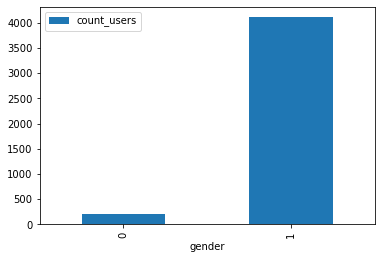

In [52]:
# визуализация рапределения по полу
gender_distr_test.plot.bar(x='gender', y='count_users')

In [53]:
# распределение количества покупок премиум по полу
test.query('product_type=="premium_no_trial"') \
    .groupby('gender', as_index=False) \
    .agg(count_purchase=('payment_id', 'count'))

,gender,count_purchase
0,1,76


Премиум подписки покупают только мужчины

### Контрольная группа 1

In [54]:
control_1 = users_control_1.merge(transactions_control_1, on='uid', how='left')
# Заменяем Nan в revenue на 0
control_1.revenue = control_1.revenue.fillna(0).astype(int)
control_1.head()

,uid,age,attraction_coeff,coins,country_x,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,country_y,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,892319115,25,435,0.0,United States of America,"[1, 2, 3, 4, 5, 6]",0,22,32,982,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
1,891248523,29,500,0.0,United States of America,"[1, 2]",1,26,32,12,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
2,891670932,33,800,0.0,France,"[1, 2, 3, 5, 6, 8, 9, 11, 13, 16]",1,30,36,5,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
3,891060786,26,0,0.0,Argentina,"[1, 2, 3, 4, 5]",1,23,29,0,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
4,892006554,35,294,0.0,United States of America,"[1, 2, 3, 5, 6, 7, 8, 9, 10, 12, 15, 16, 17, 19]",1,30,40,17,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN


In [55]:
# число уникальных пользователей в контрольной группе 1
control_1.uid.nunique()

4340

In [56]:
# дата самой первой оплаты в рамках исследуемого периода
min(control_1.query('paid_at.notna()').joined_at)

Timestamp('2015-01-19 11:49:00')

In [57]:
# дата самой последней оплаты в рамках исследуемого периода
max(control_1.query('paid_at.notna()').joined_at)

Timestamp('2017-10-31 22:17:00')

Временной период сбора данных примерно совпадает с тестовой группой

In [58]:
# число пользователей, у которых есть в данный момент подписка премиум
control_1.query('is_premium==1').uid.nunique()

192

In [59]:
# число пользователей, у которых есть премиум подписка и покупки по premium_no_trial
control_1.query('is_premium==1 and product_type=="premium_no_trial"').uid.nunique()

87

In [60]:
# число пользователей у которых была премиум-подписка, но они не совершали покупок в рассматриваемом периоде
control_1.query('total_revenue==0 and was_premium==1').uid.nunique()

257

In [61]:
# число пользователей, у которых была подписка премиум, но они ее отменили
control_1.query('was_premium==1 and is_premium==0').uid.nunique()

244

In [62]:
# Количество пользователей, не имевших и не имеющих премиум подписки
control_1.query('was_premium==0 and is_premium==0').uid.nunique()

3904

**Большинство пользователей не имели и не имеют в рассматриваемый период подписок премиум (в том числе промо).** 

Посчитаем долю таких пользователей в группе

In [63]:
str(round(control_1.query('was_premium==0 and is_premium==0').uid.nunique() * 100 / test.uid.nunique(), 2)) + '%'

'90.62%'

In [64]:
# средняя выручка по платной премиум подписке
control_1.query('product_type=="premium_no_trial"').revenue.mean()

7351.5

In [65]:
# Количество покупок премиум подписок у пользователей
count_prem_c1 = control_1.query('product_type=="premium_no_trial"') \
    .groupby('uid', as_index=False) \
    .agg(count_purchases=('uid', 'count')) \
    .sort_values('count_purchases', ascending=False)
count_prem_c1

,uid,count_purchases
51,891822480,2
96,892393119,2
94,892366260,2
5,891216033,2
67,892101909,2
...,...,...
29,891452706,1
28,891416007,1
27,891409599,1
26,891383310,1


In [66]:
# Общее количество покупок премиум подписок
count_prem_c1.count_purchases.sum()

106

In [67]:
# Доля, которую занимают покупки премиум подписок в общем выручке
round(control_1.query('product_type=="premium_no_trial"').revenue.sum()/control_1.query('product_type!="premium_no_trial"').revenue.sum(), 2)

0.43

In [68]:
# распределение пользователей по полу
gender_distr_c1 = control_1.groupby('gender', as_index=False).agg(count_users=('uid', 'nunique'))
gender_distr_c1.gender = gender_distr_c1.gender.astype(str)
gender_distr_c1 = gender_distr_c1
gender_distr_c1


,gender,count_users
0,0,182
1,1,4158


В контрольной группе 1 также преобрадают мужчины

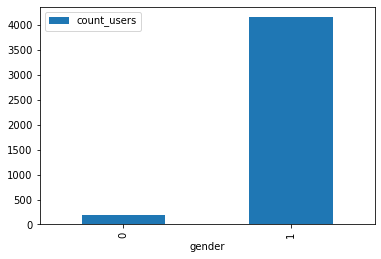

In [69]:
# визуализация рапределения по полу
gender_distr_c1.plot.bar(x='gender', y='count_users')


In [70]:
# распределение количества покупок премиум по полу
gender_dist_c1 = control_1.query('product_type=="premium_no_trial"') \
    .groupby('gender', as_index=False) \
    .agg(count_purchase=('payment_id', 'count'))
gender_dist_c1

,gender,count_purchase
0,1,106


В контрольной группе 1 также премиум подписки покупают только мужчины

### Контрольная группа 2

In [71]:
control_2 = users_control_2.merge(transactions_control_2, on='uid', how='left')
# Заменяем Nan в revenue на 0
control_2.revenue = control_2.revenue.fillna(0).astype(int)
control_2.head()

,uid,age,attraction_coeff,coins,country_x,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue,country_y,joined_at,paid_at,revenue,payment_id,from_page,product_type
0,892035504,37,137,0.0,Israel,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 13]",1,30,40,51,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
1,891782112,57,0,0.0,Italy,[1],1,54,60,0,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
2,891110337,30,769,0.0,France,"[1, 2, 3, 4, 5]",1,27,33,13,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
3,891796320,48,750,0.0,France,"[1, 4, 6, 8, 10, 11, 12, 14, 15, 16, 18]",1,45,51,12,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN
4,891880212,54,638,0.0,United States of America,[1],1,35,53,94,0,0,0,NaN,NaT,NaT,0,NaN,NaN,NaN


In [72]:
# число уникальных пользователей в контрольной группе 1
control_2.uid.nunique()

4264

In [73]:
# дата самой первой оплаты в рамках исследуемого периода
min(control_2.query('paid_at.notna()').joined_at)

Timestamp('2017-01-11 08:36:00')

In [74]:
# дата самой последней оплаты в рамках исследуемого периода
max(control_2.query('paid_at.notna()').joined_at)

Timestamp('2017-10-31 17:43:00')

Временной период сбора данных примерно совпадает с тестовой группой

In [75]:
# число пользователей, у которых есть в данный момент подписка премиум
control_2.query('is_premium==1').uid.nunique()

191

In [76]:
# число пользователей, у которых есть премиум подписка и покупки по premium_no_trial
control_2.query('is_premium==1 and product_type=="premium_no_trial"').uid.nunique()

92

In [77]:
# число пользователей у которых была премиум-подписка, но они не совершали покупок в рассматриваемом периоде
control_2.query('total_revenue==0 and was_premium==1').uid.nunique()

236

In [78]:
# число пользователей, у которых была подписка премиум, но они ее отменили
control_2.query('was_premium==1 and is_premium==0').uid.nunique()

220

In [79]:
# Количество пользователей, не имевших и не имеющих премиум подписки
control_2.query('was_premium==0 and is_premium==0').uid.nunique()

3853

**Большинство пользователей не имели и не имеют в рассматриваемый период подписок премиум (в том числе промо).** 

Посчитаем долю таких пользователей в группе

In [80]:
str(round(control_2.query('was_premium==0 and is_premium==0').uid.nunique() * 100 / test.uid.nunique(), 2)) + '%'

'89.44%'

In [81]:
# средняя выручка по платной премиум подписке
control_2.query('product_type=="premium_no_trial"').revenue.mean().round(2)

6960.83

In [82]:
# Количество покупок премиум подписок у пользователей
control_1.query('product_type=="premium_no_trial"') \
    .groupby('uid', as_index=False) \
    .agg(count_purchases=('uid', 'count')) \
    .sort_values('count_purchases', ascending=False)

,uid,count_purchases
51,891822480,2
96,892393119,2
94,892366260,2
5,891216033,2
67,892101909,2
...,...,...
29,891452706,1
28,891416007,1
27,891409599,1
26,891383310,1


In [83]:
round(control_2.query('product_type=="premium_no_trial"').revenue.sum()/control_2.query('product_type!="premium_no_trial"').revenue.sum(), 2)

0.63

In [84]:
# распределение пользователей по полу
gender_distr_c2 = control_2.groupby('gender', as_index=False).agg(count_users=('uid', 'nunique'))
gender_distr_c2.gender = gender_distr_c2.gender.astype(str)

gender_distr_c2

,gender,count_users
0,0,195
1,1,4069


В контрольной группе 2 большая часть пользователей также мужчины

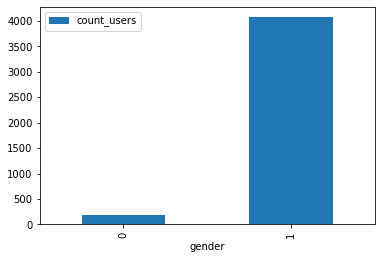

In [85]:
# визуализация рапределения по полу
gender_distr_c2.plot.bar(x='gender', y='count_users')

In [86]:
# распределение количества покупок премиум по полу
gender_dist_c2 = control_2.query('product_type=="premium_no_trial"') \
    .groupby('gender', as_index=False) \
    .agg(count_purchase=('payment_id', 'count'))
gender_dist_c2

,gender,count_purchase
0,0,5
1,1,102


В контрольной группе 2 покупки премиум подписок совершали не только мужчины, 5 покупок было совершено пользователями женского пола. Посчитаем, какой процент от общего числа покупок премиум подписок составляют покупки, совершенные женщинами.

In [87]:
round(gender_dist_c2.count_purchase[0] * 100 / gender_dist_c2.count_purchase[1], 2)

4.9

Почти 5% 

**В целом в контрольных группах довольно схожее распределение по основным переменным, но значительно отличается доля выручки от премиум-подписок в общей выручке. Есть небольшие различия в рапределении покупок премиум подписок по полу**

## A/A тест

Поскольку у нас есть 2 контрольные группы, мы можем предварительно провести тест для сравнения этих групп на предмет эффективности сплитования. От этого будет сильно зависеть наше дальнейшее исследование. Контрольные группы не должны  иметь статистически значимых различий. 

**Переменные для А/А теста:**
- пол
- возраст
- страна
- выручка (total_revenue)

Будем использовать датафреймы users_control_1 и users_control_2

### Исследование по переменной "возраст"

Сначала проверим нормальность распределения данных по возрасту в контрольной группе 1. Для этого используем normaltest и посмотрим на визуализацию распределения данных.

In [88]:
normaltest(users_control_1.age)

NormaltestResult(statistic=915.0440353937774, pvalue=1.9985377915069124e-199)

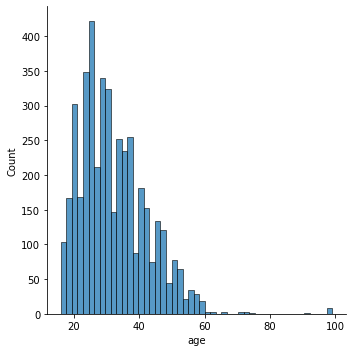

In [89]:
sns.displot(users_control_1.age)

Из полученных данных видно, что распределение по возрасту в контрольной группе 1 скошенно вправо и имеет выбросы, p-value<0.05 то есть не является нормальным. 

Проверим нормальность распределения данных по возрасту в контрольной группе 2. Для этого также используем normaltest и посмотрим на визуализацию распределения данных.

In [90]:
normaltest(users_control_2.age)

NormaltestResult(statistic=628.1035585763549, pvalue=4.064856544644868e-137)

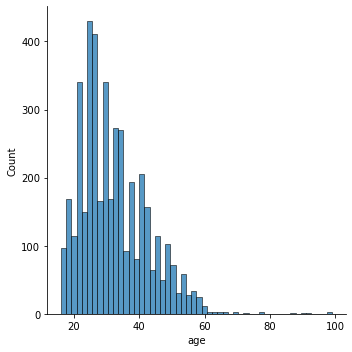

In [91]:
sns.displot(users_control_2.age)

Аналогично видно, что распределение по возрасту в контрольной группе 2 скошенно вправо и имеет выбросы, p-value<0.05 то есть не является нормальным. 

**Используем t-тест для возраста**


In [168]:
ttest_ind(users_control_1.age, users_control_2.age)

TtestResult(statistic=0.22334101484182498, pvalue=0.823275411460686, df=8602.0)

P-value > 0.05, что говорит об отсутствии статистически значимых отличий в распределении по возрасту между двумя контрольными группами

### Исследование по переменной "выручка"

Сначала проверим нормальность распределения данных по выручке в контрольной группе 1. Для этого используем normaltest и посмотрим на визуализацию распределения данных. Поскольку у нас очень много пользователей с total_revenue = 0, отфильтруем эти строки, чтобы избавиться от большого выброса в данных.

In [93]:
normaltest(users_control_1.query('total_revenue!=0').total_revenue)

NormaltestResult(statistic=401.35969083907673, pvalue=7.012138817087341e-88)

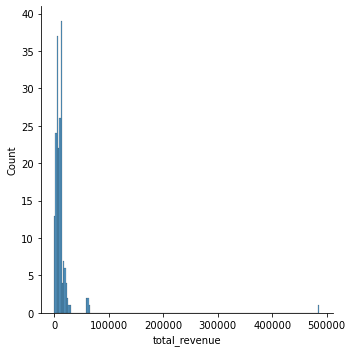

In [94]:
sns.displot(users_control_1.query('total_revenue!=0').total_revenue)

In [95]:
normaltest(users_control_2.query('total_revenue!=0').total_revenue)

NormaltestResult(statistic=215.3678902986441, pvalue=1.7118150175720902e-47)

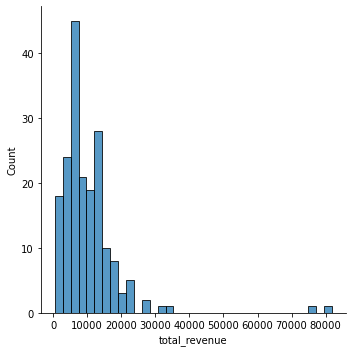

In [96]:
sns.displot(users_control_2.query('total_revenue!=0').total_revenue)

Распределения по выручке в обеих контрольных группах являются не нормальными, что вполне логично. Также в контрольной группе 1 есть очень большой выброс (> 450 000), который влияет на визуальное восприятие разницы распределений в группах. 

In [97]:
# пользователь с большим "выбросом" по выручке
users_control_1.query('total_revenue>450000')

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
1427,892333905,22,175,3608.0,Italy,"[1, 2, 3, 4, 5, 6, 7, 15]",1,19,25,575,1,1,486330


In [98]:
# это единственная транзакция этого пользователя
users_control_1.query('uid==892333905')

,uid,age,attraction_coeff,coins,country,visit_days,gender,age_filter_start,age_filter_end,views_count,was_premium,is_premium,total_revenue
1427,892333905,22,175,3608.0,Italy,"[1, 2, 3, 4, 5, 6, 7, 15]",1,19,25,575,1,1,486330


Отфильруем этот выброс из группы 1

**Используем t-тест для выручки**

In [167]:
ttest_ind(users_control_1.query('total_revenue!=0 and total_revenue<450000').total_revenue,
         users_control_2.query('total_revenue!=0').total_revenue)

TtestResult(statistic=0.7048674796354045, pvalue=0.48132909211498487, df=376.0)

P-value > 0.05, что говорит об отсутствии статистически значимых отличий в распределении по выручке между двумя контрольными группами

### Исследование по переменной "Страна"

**Используем хи-квадрат тест для страны**

Переменная "страна" категориальная, поэтому необходимо сначала подготовить данные

In [102]:
# Считаем количество пользователей по странам в контрольной группе 1
countries_1 = pd.DataFrame(users_control_1.country.value_counts() \
    .reset_index() \
    .rename(columns={'index':'country', 'country':'count_1'}))
countries_1.head()

,country,count_1
0,United States of America,1471
1,Argentina,389
2,France,370
3,Spain,342
4,Italy,338


In [103]:
# Считаем количество пользователей по странам в контрольной группе 2
countries_2 = pd.DataFrame(users_control_2.country.value_counts() \
    .reset_index() \
    .rename(columns={'index':'country', 'country':'count_2'}))
countries_2.head()

,country,count_2
0,United States of America,1486
1,Argentina,397
2,France,376
3,Spain,310
4,Italy,293


In [104]:
# Общее число стран в контрольной группе 1
countries_2.country.nunique()

45

In [105]:
# Общее число стран в контрольной группе 2
countries_1.country.nunique()

40

In [106]:
# объединим в одну таблицу
countries  = countries_2.merge(countries_1, how='left', on='country')
# заполним пропуски нулями и приведем к типу данных int столбец count_1
countries.count_1  = countries.count_1.fillna(0).astype(int)
countries = countries.set_index('country')

countries.sort_values('count_2')

,count_2,count_1
country,,
China,1,1
Georgia,1,0
Kyrgyzstan,1,1
Peru,1,1
Uruguay,1,0
Dominican Republic,1,2
Hungary,1,0
Costa Rica,1,1
Tajikistan,1,0


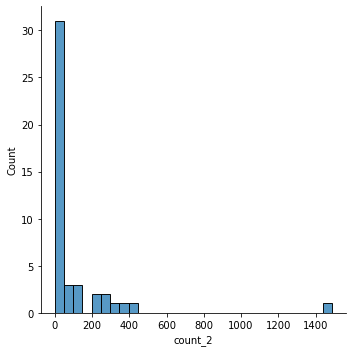

In [107]:
sns.displot(countries.count_2)

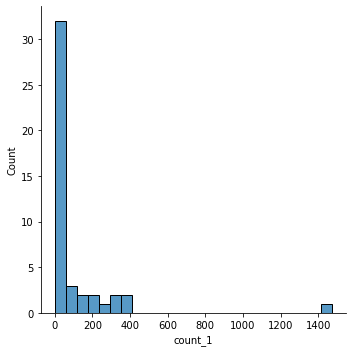

In [108]:
sns.displot(countries.count_1)

В целом распределения похожи, но в обоих группах есть довольно большая доля стран, встречающихся 1 и менее раз. Для более точной оценки, возьмем страны, встречающиеся больше 5 раз

In [109]:
# создаем таблицу сопряженности
country_table = countries.query('count_1>5 and count_2>5').T
country_table

country,United States of America,Argentina,France,Spain,Italy,Chile,United Arab Emirates,Germany,United Kingdom (Great Britain),Canada,Portugal,Belgium,Israel,Australia,Switzerland,Ukraine,Russian Federation
count_2,1486,397,376,310,293,286,211,202,146,134,100,90,78,51,35,18,8
count_1,1471,389,370,342,338,287,207,188,146,134,100,108,109,50,42,8,6


In [110]:
# используем хи-квадрат тест для страны
country_chi2, country_p, country_dof, country_expected = chi2_contingency(country_table)
country_p

0.4227062323969844

P-value > 0.05, что говорит об отсутствии статистически значимых отличий в распределении по странам между двумя контрольными группами

*Проверка условий хи-квадрат:*
1. Не более 20% ячеек должны иметь expected frequency < 5
2. Ни одна ячейка не должна иметь expected frequency < 1

expected frequencies - ожидаемые частоты для каждой ячейки таблицы сопряженности, рассчитанные в предположении, что нулевая гипотеза H₀ верна (нет статистически занчимых различий в распределении по странам между двумя контрольными группами).

In [111]:
# Проверяем условия для хи-квадрат теста
expected_below_5 = (country_expected < 5).sum()
expected_below_1 = (country_expected < 1).sum()
total_cells = country_expected.size

condition_violated = (expected_below_5 / total_cells < 0.2) or (expected_below_1 == 0)
condition_violated

True

Условия для хи-квадрат теста соблюдаются

### Исследование по переменной "пол"

**Используем хи-квадрат тест для пола**

Пол - переменная категориальная, бинарная.

In [112]:
gender_1 = users_control_1['gender'].value_counts()
gender_1

1    4158
0     182
Name: gender, dtype: int64

In [113]:
gender_2 = users_control_2['gender'].value_counts()
gender_2

1    4069
0     195
Name: gender, dtype: int64

In [114]:
genders = pd.concat([gender_1, gender_2], axis=1)
genders

,gender,gender
1,4158,4069
0,182,195


In [115]:
# Таблица сопряженности
gender_table = genders.T
gender_table

,1,0
gender,4158,182
gender,4069,195


In [116]:
# используем хи-квадрат тест для пола
gender_chi2, gender_p, gender_dof, gender_expected = chi2_contingency(gender_table)
gender_p

0.41940247806709796

P-value > 0.05, что говорит об отсутствии статистически значимых отличий в распределении по полу между двумя контрольными группами

In [117]:
# Проверяем условия для хи-квадрат теста
expected_below_5 = (gender_expected < 5).sum()
expected_below_1 = (gender_expected < 1).sum()
total_cells = gender_expected.size

condition_violated = (expected_below_5 / total_cells < 0.2) or (expected_below_1 == 0)
condition_violated

True

Условия для хи-квадрат теста соблюдаются

### Проверим различается ли распределение покупок премиум подписок по полу между контрольными группами 1 и 2.

Для этого построим таблицу сопряженности.

In [118]:
gender_dist = gender_dist_c2.merge(gender_dist_c1, on='gender', how='left').fillna(0).astype(int)
gender_dist = gender_dist.rename(columns={'count_purchase_x': 'count_c2', 'count_purchase_y': 'count_c1'}) \
    .pivot_table(columns='gender')
gender_dist

gender,0,1
count_c1,0,106
count_c2,5,102


In [119]:
# применяем хи-квадрат-тест

dist_purchases_chi2, dist_purchases_p, dist_purchases_dof, dist_purchases_expected = chi2_contingency(gender_dist)
dist_purchases_p

0.07192006227921688

p-value = 0.072 > 0.05

Это означает, что нет статистически значимых различий в распределении покупок по полу между двумя контрольными группами.

In [120]:
# Проверяем условия для хи-квадрат теста
expected_below_5 = (dist_purchases_expected < 5).sum()
expected_below_1 = (dist_purchases_expected < 1).sum()
total_cells = dist_purchases_expected.size

condition_violated = (expected_below_5 / total_cells < 0.2) or (expected_below_1 == 0)
condition_violated

True

Условия для хи-квадрат теста соблюдаются

### Вывод по A/A тесту:

По результатам проведенных тестов можно сказать, что в контрольных группах нет статистически значимых различий по выбранных переменным (пол, возраст, страна, общая нормированная выручка, распределение числа покупок премиум подписок по полу).

Но нужно учитывать, что в контрольной группе 1 есть большой выброс по выручке у пользователя uid=892333905 (единственная транзакция у данного пользователя). 

Поэтому для дальнейшего анализа A/B теста будем сранивать тестовую группу и контрольную группу 2. Это также поможет избежать проблему множественного тестирования.

## Предположение о гипотезе A/B теста и выбор метрик для оценки результатов

В данных нет информации о выдвигаемой гипотезе, также не сказано, как именно изменилась цена премиум подписки для тестовой группы (уменьшилась или увеличилась). 

**Вариант 1**: Цена премиум подписки была увеличена в тестовой группе. Ожидается, что средняя выручка на платящего пользователя должна вырасти за счет роста цены премиум подписки. При этом это может спровоцировать отток покупок в данном сегменте, а также рост числа отмен премиум подписок, поэтому мы можем наблюдать как рост метрики (покупок премиум стало меньше, но рост цены компенсировал отток покупок), так и ее снижение.

**Нулевая гипотеза (H0)**: Увеличение цены премиум-подписки не привело к статистически значимому изменению метрик.              
**Альтернативная гипотеза (H1)**: Увеличение цены премиум-подписки привело к статистически значимому изменению метрик.

**Метрики для анализа эффективности эксперимента в соответствие с гипотезой 1**:
1. Целевая: Выручка с продаж премиум подписок
2. Прокси: ARPPU
3. guardrail: Сhurn rate (доля отмен премиум подписок на 1 платящего пользователя)


**Вариант 2**: Цена премиум подписки была снижена в тестовой группе. Ожидается, что пользователи станут активнее приобретать премиум подписки при более привлекательной цене, вырастет конверсия в покупку премиум-подписки. 

**Нулевая гипотеза (H0)**: Уменьшение цены премиум-подписки не привело к статистически значимому изменению метрик.              
**Альтернативная гипотеза (H1)**: Уменьшение цены премиум-подписки привело к статистически значимому изменению метрик.

**Метрики для анализа эффективности эксперимента в соответствие с гипотезой 2**:
1. Целевая: Конверсия в покупку премиум-подписки
2. Прокси: Среднее число покупок по премиум-подпискам на платящего пользователя 
3. guardrail: Среднее число дней посещения приложения (премиум подписка стала дешевле, что может снизить ее ценность для пользователей)


## Расчет метрик по вариантам 1 и 2

## Вариант 1

Посчитаем метрики в тестовой и контрольных группах

**Тестовая группа**

**Выручка от покупок премиум-подписок**

In [121]:
# Считаем выручку пользователей, преобретавших премиум-подписки
premium_test = test.query('product_type=="premium_no_trial"') \
    .groupby('uid', as_index=False) \
    .agg(revenue_premium=('revenue', 'sum'))
premium_test

,uid,revenue_premium
0,891071157,9100
1,891152790,12597
2,891178380,113477
3,891222282,6292
4,891291531,4056
...,...,...
62,892370097,11115
63,892390170,5369
64,892405179,9100
65,892426491,12597


In [122]:
# Общая выручка по премиум-подпискам
revenue_premium_test = premium_test.revenue_premium.sum()
revenue_premium_test

810706

**ARPPU**

In [123]:
# Распределение выручки по пользователям
avg_rev_test = test.query('revenue!=0').groupby('uid', as_index=False).agg(avg_rev=('revenue', 'sum'))
avg_rev_test

,uid,avg_rev
0,891071157,9100
1,891152790,12597
2,891174411,28080
3,891175326,897
4,891178380,129870
...,...,...
141,892426491,12597
142,892430988,12727
143,892431081,9087
144,892434141,9165


In [124]:
# количество платящих пользователей
paying_users_test = test.query('revenue!=0').uid.nunique()
paying_users_test

146

In [125]:
# Средняя выручка на 1 платящего пользователя
arppu_test = round(avg_rev_test.avg_rev.sum() / paying_users_test, 2)
arppu_test

16060.97

**Количество отмен премиум подписок среди платящих пользователей**

In [126]:
# churn rate премиум подписок
churn_test = test.query('was_premium==1 and is_premium==0 and revenue!=0') \
    .groupby('uid', as_index=False) \
    .agg(churn_count = ('uid', 'count'))

In [127]:
# количество отмен премиум подписок
churn_premium_test = churn_test.churn_count.sum()
churn_premium_test 

25

Посчитаем еще долю отмен (среди платящих пользователей)

In [128]:
share_cancell_test = round(churn_premium_test * 100 / paying_users_test, 2)
share_cancell_test

17.12

Доля отмен на 1 платящего пользователя в тестовой группе примерно 17%

**Контрольная группа 2**

**Выручка от покупок премиум-подписок**

In [129]:
# Считаем выручку пользователей, приобретавших премиум-подписки
premium_c2 = control_2.query('product_type=="premium_no_trial"') \
    .groupby('uid', as_index=False) \
    .agg(revenue_premium=('revenue', 'sum'))
premium_c2

,uid,revenue_premium
0,891068079,6292
1,891077727,6292
2,891112263,4680
3,891136632,10413
4,891143379,6500
...,...,...
97,892343331,2873
98,892354854,6435
99,892364742,4797
100,892385232,6292


In [130]:
# общая выручка от премиум подписок
revenue_premium_c2 = premium_c2.revenue_premium.sum()
revenue_premium_c2

744809

**ARPPU**

In [131]:
# Распределение выручки по пользователям
avg_rev_c2 = control_2.query('revenue!=0').groupby('uid', as_index=False).agg(avg_rev=('revenue', 'sum'))
avg_rev_c2

,uid,avg_rev
0,891068079,10296
1,891075072,2327
2,891077727,6292
3,891080040,15132
4,891112263,17290
...,...,...
182,892384110,9087
183,892385232,6292
184,892395564,2730
185,892435536,13598


In [132]:
# количество платящих пользователей
paying_users_c2 = control_2.query('revenue!=0').uid.nunique()
paying_users_c2

187

In [133]:
# Средняя выручка на 1 платящего пользователя
arppu_c2 = round(avg_rev_c2.avg_rev.sum() / paying_users_c2, 2)
arppu_c2

10269.72

**Количество отмен премиум подписок**

In [134]:
# churn rate премиум подписок
churn_c_2 = control_2.query('was_premium==1 and is_premium==0 and revenue!=0') \
    .groupby('uid', as_index=False) \
    .agg(churn_count = ('uid', 'count'))

In [135]:
# количество отмен премиум подписок
churn_premium_c2 = churn_c_2.churn_count.sum()
churn_premium_c2

43

Посчитаем еще долю отмен (среди платящих пользователей)

In [136]:
share_cancell_c2 = round(churn_premium_c2 * 100 / paying_users_c2, 2)
share_cancell_c2

22.99

Доля отмен на 1 платящего пользователя в контрольной группе 2 примерно 23%

### Сравнение полученных метрик в тестовой и контрольной группе 2

In [137]:
# прирост выручки в тестовой группе по сравнению с контрольной
round((revenue_premium_test - revenue_premium_c2) * 100 / revenue_premium_c2, 2)

8.85

Выручка в тестовой группе выросла почти на 9%

In [138]:
# прирост ARPPU в тестовой группе по сравнению с контрольной
round((arppu_test - arppu_c2) * 100 / arppu_c2, 2)

56.39

Средняя выручка по премиум подпискам на платящего пользователя выросла почти на 56%!

In [139]:
# Прирост отмен премиум подписок
round((churn_premium_test - churn_premium_c2) * 100 / churn_premium_c2, 2)

-41.86

In [140]:
# Прирост доли отмен премиум подписок
round((share_cancell_test - share_cancell_c2) * 100 / share_cancell_c2, 2)

-25.53

Количество отмен премиум подписок сократилось на 42%, доля отменя на 1 платящего пользователя сократилась на 25%. В целом такое сокращение может говорит о том, что  пользователи, остающиеся после повышения цены, воспринимают премиум как более ценную и реже отменяют.

## Вариант 2

**Тестовая группа**

**Конверсия в покупку премиум-подписки**

In [141]:
conversion_test = test.query('product_type=="premium_no_trial"').product_type.count()
conversion_test

76

**Среднее количество транзакций по премиум-подпискам на платящего пользователя**

In [142]:
trans_by_user_test = round(conversion_test/test.query('revenue>0').uid.nunique(), 2)
trans_by_user_test

0.52

**Среднее число дней посещения приложения**

In [143]:
# добавим колонку с количеством дней посещения
test['count_days'] = test.visit_days.apply(lambda x: len(x))

In [144]:
avg_visit_days_test = test.query('product_type=="premium_no_trial"').count_days.mean().round(2)
avg_visit_days_test

12.87

**Контрольная группа 2**

**Конверсия в премиум подписку**

In [145]:
conversion_c2 = control_2.query('product_type=="premium_no_trial"').product_type.count()
conversion_c2

107

**Среднее количество транзакций по премиум-подпискам на платящего пользователя**

In [146]:
trans_by_user_c2 = round(conversion_c2/control_2.query('revenue>0').uid.nunique(), 2)
trans_by_user_c2

0.57

**Среднее число дней посещения приложения**

In [147]:
# добавим колонку с количеством дней посещения
control_2['count_days'] = control_2.visit_days.apply(lambda x: len(x))

In [148]:
avg_visit_days_c2 = control_2.query('product_type=="premium_no_trial"').count_days.mean().round(2)
avg_visit_days_c2

10.82

### Сравнение полученных метрик в тестовой и контрольной группе 2

Как видим, средняя посещаемость выросла, но при этом конверсия в покупку премиум подписки упала.
Вероятнее всего это означает, что наше предположение о варианте 2 (цена на премиум подписку была снижена) **было неверным**. В рамках эксперимента цена на премиум подписку была увеличена. 

Поэтому далее мы будем анализировать **только вариант 1** на предмет статистической значимости полученных результатов.

## Оценка результатов A/B теста. Анализ статистической значимости. 

### Анализ статистической значимости по выручке от продаж премиум подписок

In [149]:
# тестовая группа
normaltest(premium_test.revenue_premium)

NormaltestResult(statistic=106.541403027515, pvalue=7.325348408699735e-24)

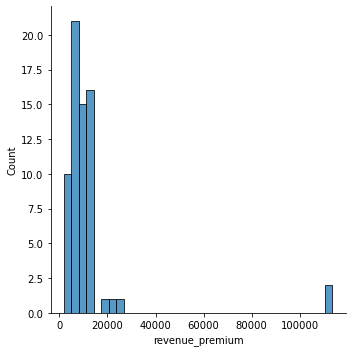

In [150]:
sns.displot(premium_test.revenue_premium)

Данные имеют ненормальное распределение

In [151]:
# контрольная группа 2
normaltest(premium_c2.revenue_premium)

NormaltestResult(statistic=171.99524134030986, pvalue=4.4844365763573417e-38)

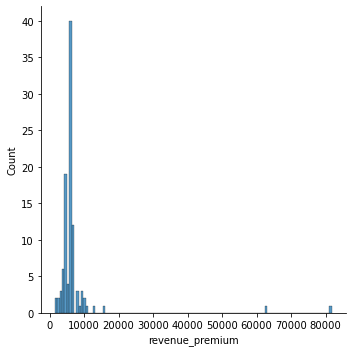

In [152]:
sns.displot(premium_c2.revenue_premium)

Данные имеют ненормальное распределение

Посмотрим также на boxplot для обеих групп

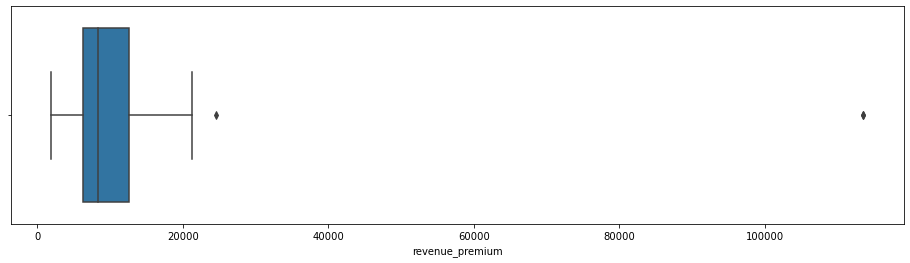

In [153]:
# тестовая группа
plt.figure(figsize=(16, 4))
sns.boxplot(data = premium_test, x = 'revenue_premium')

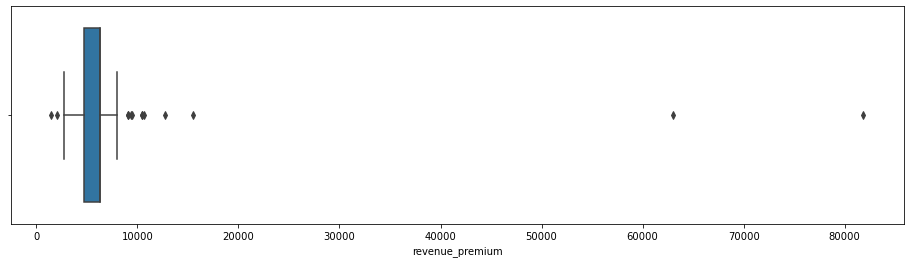

In [154]:
# контрольная группа 2
plt.figure(figsize=(16, 4))
sns.boxplot(data = premium_c2, x = 'revenue_premium')

Проведем тест Левена для проверки равенства дисперсий в тестовой и контрольной группе

In [155]:
levene(premium_test.revenue_premium, premium_c2.revenue_premium)

LeveneResult(statistic=2.8859194364149365, pvalue=0.09121916089702657)

P-value > 0.05, значит, нет статистически значимых различий в дисперсиях между группами. 

Значение p-value и визуализация показывают, что данные в обеих группах распределены не нормально, имеются большие выбросы, хотя дисперсии статистически значимо не отличаются. При этом у нас достаточно большие по объему выборки и мы можем использовать t-тест с оговоркой на ненормальность распределения данных, он даст быстрый результат для оценки. Также предлагаю использовать дополнительно метод Bootstrap для более надежной оценки и сравнить результат с t-тестом.

**t-тест**

In [156]:
ttest_ind(premium_test.revenue_premium, premium_c2.revenue_premium)

TtestResult(statistic=2.2223015888657454, pvalue=0.027606185138531043, df=167.0)

P-value < 0.05. Значит, мы получили статистически значимое различие по выручке от покупок премиум-подписок в тестовой и контрольной группе 2 (с оговоркой о ненормальности рапределения данных при большом объеме выборки). 

**Bootstrap**

In [157]:
np.random.seed(42)

def bootstrap_test(test_data, control_data, n_iterations=10000, ci=95):
    
    n_test = len(test_data)
    n_control = len(control_data)
    
    # Храним разницы средних для каждой итерации
    bootstrap_diffs = np.zeros(n_iterations)
    
    # Наблюдаемая разница
    observed_diff = np.mean(test_data) - np.mean(control_data)
    
    for i in range(n_iterations):
        bs_test = np.random.choice(test_data, n_test, replace=True)
        bs_control = np.random.choice(control_data, n_control, replace=True)
        bootstrap_diffs[i] = np.mean(bs_test) - np.mean(bs_control)
    
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)
    
    p_val = 2 * min(np.mean(bootstrap_diffs <= 0), np.mean(bootstrap_diffs >= 0))
    
    return observed_diff, ci_lower, ci_upper, p_val

obs_diff, ci_lower, ci_upper, p_val = bootstrap_test(premium_test.revenue_premium, premium_c2.revenue_premium)

print(f"Разница: {obs_diff:.4f}")
print(f"95% доверительный интервал: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"P-value: {p_val:.6f}")

Разница: 4798.0405
95% доверительный интервал: [624.0710, 10172.9607]
P-value: 0.022200


**Интерпритация результата Bootstrap**: 
1. Тестовая группа в среднем приносит на 4798.04 денежных единиц больше, чем контрольная.
2. P-value = 0.0222 < 0.05. Результат статистически значим. Вероятность получить такую разницу случайно (при условии, что группы на самом деле одинаковы) составляет всего 1.78%.
3. 95% доверительный интервал: [624.0710, 10172.9607]. Нижняя граница > 0, значит с 95% уверенностью можем сказать, что тестовая группа точно лучше контрольной. При этом интервал довольно широкий (от 624 до 10172), что говорит о большой неопределенности в оценке размера эффекта.

В целом t-тест и  Bootstrap дали нам схожий результат: мы наблюдаем статистически значимую разницу средним в тестовой и контрольной группах, но Bootstrap позволяет взглянуть на ситуацию шире: размер эффекта обладает большой неопределнностью.

### Анализ статистической значимости по ARPPU

**Для анализа стат. значимости результатов по ARPPU будем использовать таблицы распределения выручки по пользователям, так как при рассчете ARPPU в знаменателе у нас общее число платящих пользователей.**

Посмотрим на распределение данных в группах, их нормальность и равенство дисперсий.

In [158]:
# тестовая группа
normaltest(avg_rev_test.avg_rev)

NormaltestResult(statistic=154.2612274514466, pvalue=3.181266653116086e-34)

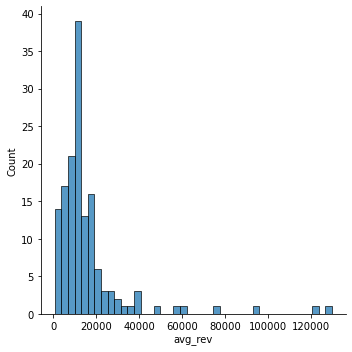

In [159]:
sns.displot(avg_rev_test.avg_rev)

In [160]:
# контрольная группа 
normaltest(avg_rev_c2.avg_rev)

NormaltestResult(statistic=215.36789029864406, pvalue=1.7118150175721398e-47)

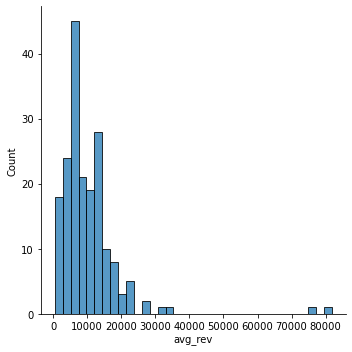

In [161]:
sns.displot(avg_rev_c2.avg_rev)

Данные также имеют ненормальное распределение.

Посмотрим также на boxplot для обеих групп.

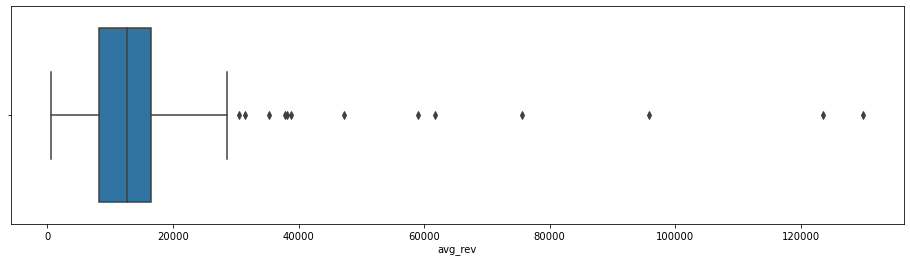

In [162]:
# тестовая группа
plt.figure(figsize=(16, 4))
sns.boxplot(data = avg_rev_test, x = 'avg_rev')

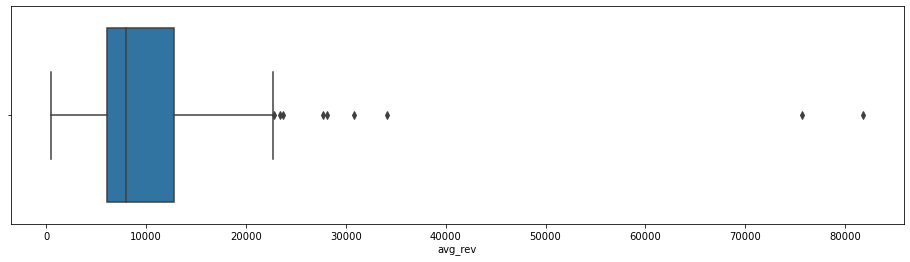

In [163]:
# контрольная группа
plt.figure(figsize=(16, 4))
sns.boxplot(data = avg_rev_c2, x = 'avg_rev')

Проведем тест Левена для проверки равенства дисперсий в тестовой и контрольной группе

In [164]:
levene(avg_rev_test.avg_rev, avg_rev_c2.avg_rev)

LeveneResult(statistic=5.696976208845359, pvalue=0.01755529522246975)

P-value < 0.05, значит, есть статистически значимые различия в дисперсиях между группами! Распределены данные ненормально, поэтому мы не можем использовать t-тест. Будем использовать Bootstrap.

In [165]:
np.random.seed(42)

def bootstrap_test_arppu(test_data, control_data, n_iterations=10000, ci=95):
    
    n_test = len(test_data)
    n_control = len(control_data)
    
    # Храним разницы средних для каждой итерации
    bootstrap_diffs = np.zeros(n_iterations)
    
    # Наблюдаемая разница
    observed_diff = np.mean(test_data) - np.mean(control_data)
    
    for i in range(n_iterations):
        bs_test = np.random.choice(test_data, n_test, replace=True)
        bs_control = np.random.choice(control_data, n_control, replace=True)
        bootstrap_diffs[i] = np.mean(bs_test) - np.mean(bs_control)
    
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)
    
    p_val = 2 * min(np.mean(bootstrap_diffs <= 0), np.mean(bootstrap_diffs >= 0))
    
    return observed_diff, ci_lower, ci_upper, p_val

obs_diff, ci_lower, ci_upper, p_val = bootstrap_test_arppu(avg_rev_test.avg_rev, avg_rev_c2.avg_rev)

print(f"Разница: {obs_diff:.4f}")
print(f"95% доверительный интервал: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"P-value: {p_val:.6f}")

Разница: 5791.2438
95% доверительный интервал: [2710.2408, 9243.0606]
P-value: 0.000000


**Интерпритация результата Bootstrap**: 
1. Тестовая группа в среднем приносит на 5791.2 денежных единиц больше, чем контрольная.
2. P-value = 0.0 < 0.05. Результат статистически значим. Вероятность получить такую разницу случайно (при условии, что группы на самом деле одинаковы) составляет фактически 0%.
3. 95% доверительный интервал: [2710.2408, 9243.0606]. Нижняя граница > 0, значит с 95% уверенностью можем сказать, что тестовая группа точно лучше контрольной. При этом интервал довольно широкий (от 2710 до 9243), что говорит о большой неопределенности в оценке размера эффекта.

### Анализ статистической значимости по churn rate (отмена премиум подписок)

Будем использовать z-тест пропорциональности

In [169]:
count = np.array([churn_premium_test, churn_premium_c2])  
nobs = np.array([paying_users_test, paying_users_c2])     

z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

test_churn_rate = churn_premium_test / paying_users_test
control_churn_rate = churn_premium_c2 / paying_users_c2

diff = test_churn_rate - control_churn_rate
se = np.sqrt(test_churn_rate*(1-test_churn_rate)/paying_users_test + 
             control_churn_rate*(1-control_churn_rate)/paying_users_c2)
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print(f"  Z-статистика: {z_stat:.3f}")
print(f"  P-value: {p_value:.6f}")

print(f"\nДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (95%):")
print(f"  Разница: {diff*100:+.3f} п.п.")
print(f"  ДИ: [{ci_lower*100:+.3f} п.п., {ci_upper*100:+.3f} п.п.]")


  Z-статистика: -1.319
  P-value: 0.187234

ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ (95%):
  Разница: -5.871 п.п.
  ДИ: [-14.457 п.п., +2.714 п.п.]


P-value = 0.187 > 0.05, что говорит о том, что различия статистически не значимы. С 95% уверенностью реальный эффект может быть:
- Улучшение до -14.457 п.п. (лучший сценарий)
- Ухудшение до +2.714 п.п. (худший сценарий)

## Выводы:

1. Z-тест не подтверждает статистически значимого влияния повышения цены на churn rate. Но тем не менее в тестовой группе доля отмен премиум подписок снизилась по сравнению с контрольной. 


2. Эксперимент выглядит удачным, так как целевая метрика и прокси-метрика показали статистически значимый рост, а guardrail-метрика не ухудшилась статистически значимо. Рост ARPPU при стабильной доле отмен может указывать на то, что новая ценовая политика лучше отсеивает "халявщиков" и/или привлекает более лояльных и платежеспособных пользователей, которые выше ценят сервис. 


3. Введение двух новых платежных систем могло увеличивать конверсию на уровне покупки премиум-подписки и увеличивать ARPPU за счет повышения удобства оплаты, вариантов оплаты или оптимизации процесса покупки.


4. Широкие доверительные интервалы по финансовым метрикам не позволяют точно оценить масштаб эффекта. Мы можем получить незначительный положительный эффект по выручке от премиум подписок (нижняя граница доверительного интервала) и при этом в долгосрочной перспективе получить отток пользователей, снижение LTV.

### Предложения по дальнейших действиям:

1. Уточнить сегментацию: проанализировать эффект по сегментам пользователей (возраст, страна, пол, тип платежной системы) для выявления наиболее чувствительных групп.

2. Проверить совместимость с другими промо-акциями: исследовать, как совместная работа новых платежных систем и будущих бонусов/скидок влияет на выручку и ARPPU.

3. Мониторинг риска: продолжать следить за guardrail, чтобы оперативно обнаружить любые изменения в доле отмен, особенно при расширении теста.

4. A/B-тест по цене в каждой платежной системе (в рамках теста) для оптимизации стоимости премиум-подписки.

5. Для принятия окончательного решения по масштабированию экперимента оценить экономический эффект и окупаемость.


### Итоговый вывод: 
### Эксперимент успешен, но требует дополнительного анализа данных для понимания реального размера эффекта и принятия взвешенного решения о масштабировании. 